# Exploratory Data Analysis (EDA) — Corrected Gibbs Project

**Project:** Bayesian Regime Detection via Gibbs Sampling
**Datasets:** S&P 500 · NIFTY 50 · US Recession Indicator

> **Note on the prior version:** An earlier implementation contained a silent bug
> in the Gibbs sampler — the return value of `ffbs()` was never assigned back to
> `S`, so latent states never actually updated. All analysis in this folder uses
> the corrected implementation.

---
### Sections
1. Data Loading & Shape  
2. Missing Values  
3. Descriptive Statistics  
4. Historical Price Trends  
5. Log Return Time Series  
6. Return Distributions (Histogram + KDE)  
7. Q–Q Plots (Normality Check)  
8. Rolling Volatility (21-Week Window)  
9. Autocorrelation (ACF) of Returns & Squared Returns  
10. Correlation Between Markets  
11. Regime Context: NBER Recessions  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RECESSION_COLOR = "#e74c3c"
SP_COLOR        = "#3498db"
NIF_COLOR       = "#2ecc71"


In [2]:
sp500 = pd.read_csv("sp500_data.csv", index_col="Date")
nifty = pd.read_csv("nifty50_data.csv", index_col="Date")
rec   = pd.read_csv("us_recession.csv", index_col="observation_date")

sp500.index = pd.to_datetime(sp500.index, utc=True).tz_localize(None)
nifty.index  = pd.to_datetime(nifty.index,  utc=True).tz_localize(None)
rec.index    = pd.to_datetime(rec.index)

print("S&P 500 :", sp500.shape, "| Range:", sp500.index.min().date(), "→", sp500.index.max().date())
print("NIFTY 50:", nifty.shape,  "| Range:", nifty.index.min().date(),  "→", nifty.index.max().date())


S&P 500 : (1111, 6) | Range: 2005-01-01 → 2026-04-11
NIFTY 50: (970, 6) | Range: 2007-09-16 → 2026-04-12


## 2. Missing Values

In [3]:
print("=== Missing Values ===")
print("S&P 500:\n",  sp500.isnull().sum())
print("\nNIFTY 50:\n", nifty.isnull().sum())
sp500.dropna(subset=["Log_Return"], inplace=True)
nifty.dropna(subset=["Log_Return"], inplace=True)
print("\nAfter drop — SP500:", len(sp500), "  NIFTY:", len(nifty))


=== Missing Values ===
S&P 500:
 Open          0
High          0
Low           0
Close         0
Volume        0
Log_Return    1
dtype: int64

NIFTY 50:
 Open          0
High          0
Low           0
Close         0
Volume        0
Log_Return    1
dtype: int64

After drop — SP500: 1110   NIFTY: 969


## 3. Descriptive Statistics

In [4]:
summary = pd.DataFrame({
    "S&P 500 Returns" : sp500["Log_Return"],
    "NIFTY 50 Returns": nifty["Log_Return"],
}).describe().T

for name, col in [("S&P 500 Returns", sp500["Log_Return"]),
                  ("NIFTY 50 Returns", nifty["Log_Return"])]:
    summary.loc[name, "skewness"] = col.skew()
    summary.loc[name, "kurtosis"] = col.kurtosis()

display(summary[["count","mean","std","min","25%","50%","75%","max","skewness","kurtosis"]].round(6))


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
S&P 500 Returns,1110.0,0.001615,0.024421,-0.200838,-0.009655,0.002835,0.014588,0.114237,-0.943546,8.410627
NIFTY 50 Returns,969.0,0.001668,0.027101,-0.173755,-0.012355,0.003314,0.015889,0.143568,-0.441884,5.049266


## 4. Historical Price Trends

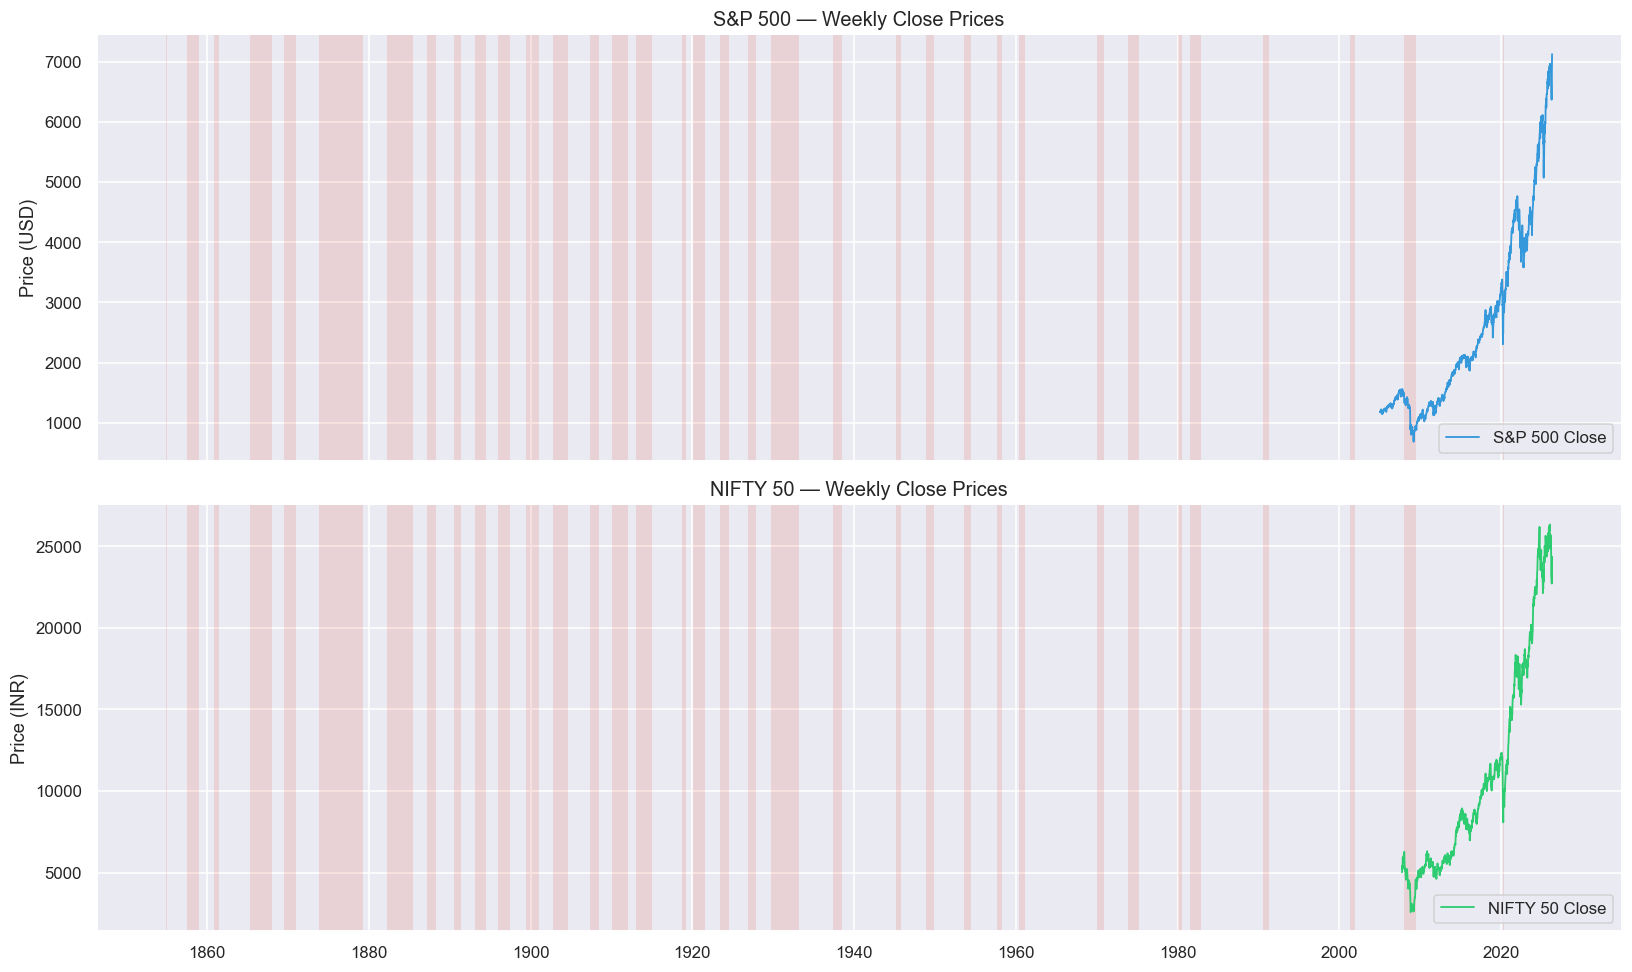

In [5]:
def shade_recessions(ax, df_rec):
    mask = df_rec["USREC"] == 1
    in_rec, start = False, None
    for date, val in mask.items():
        if val and not in_rec:  start, in_rec = date, True
        elif not val and in_rec:
            ax.axvspan(start, date, color=RECESSION_COLOR, alpha=0.15, lw=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, df_rec.index[-1], color=RECESSION_COLOR, alpha=0.15, lw=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(sp500.index, sp500["Close"], color=SP_COLOR, lw=1.2, label="S&P 500 Close")
axes[0].set_title("S&P 500 — Weekly Close Prices", fontsize=13); axes[0].set_ylabel("Price (USD)")
shade_recessions(axes[0], rec); axes[0].legend()
axes[1].plot(nifty.index, nifty["Close"], color=NIF_COLOR, lw=1.2, label="NIFTY 50 Close")
axes[1].set_title("NIFTY 50 — Weekly Close Prices", fontsize=13); axes[1].set_ylabel("Price (INR)")
shade_recessions(axes[1], rec); axes[1].legend()
plt.tight_layout(); plt.show()


## 5. Log Return Time Series

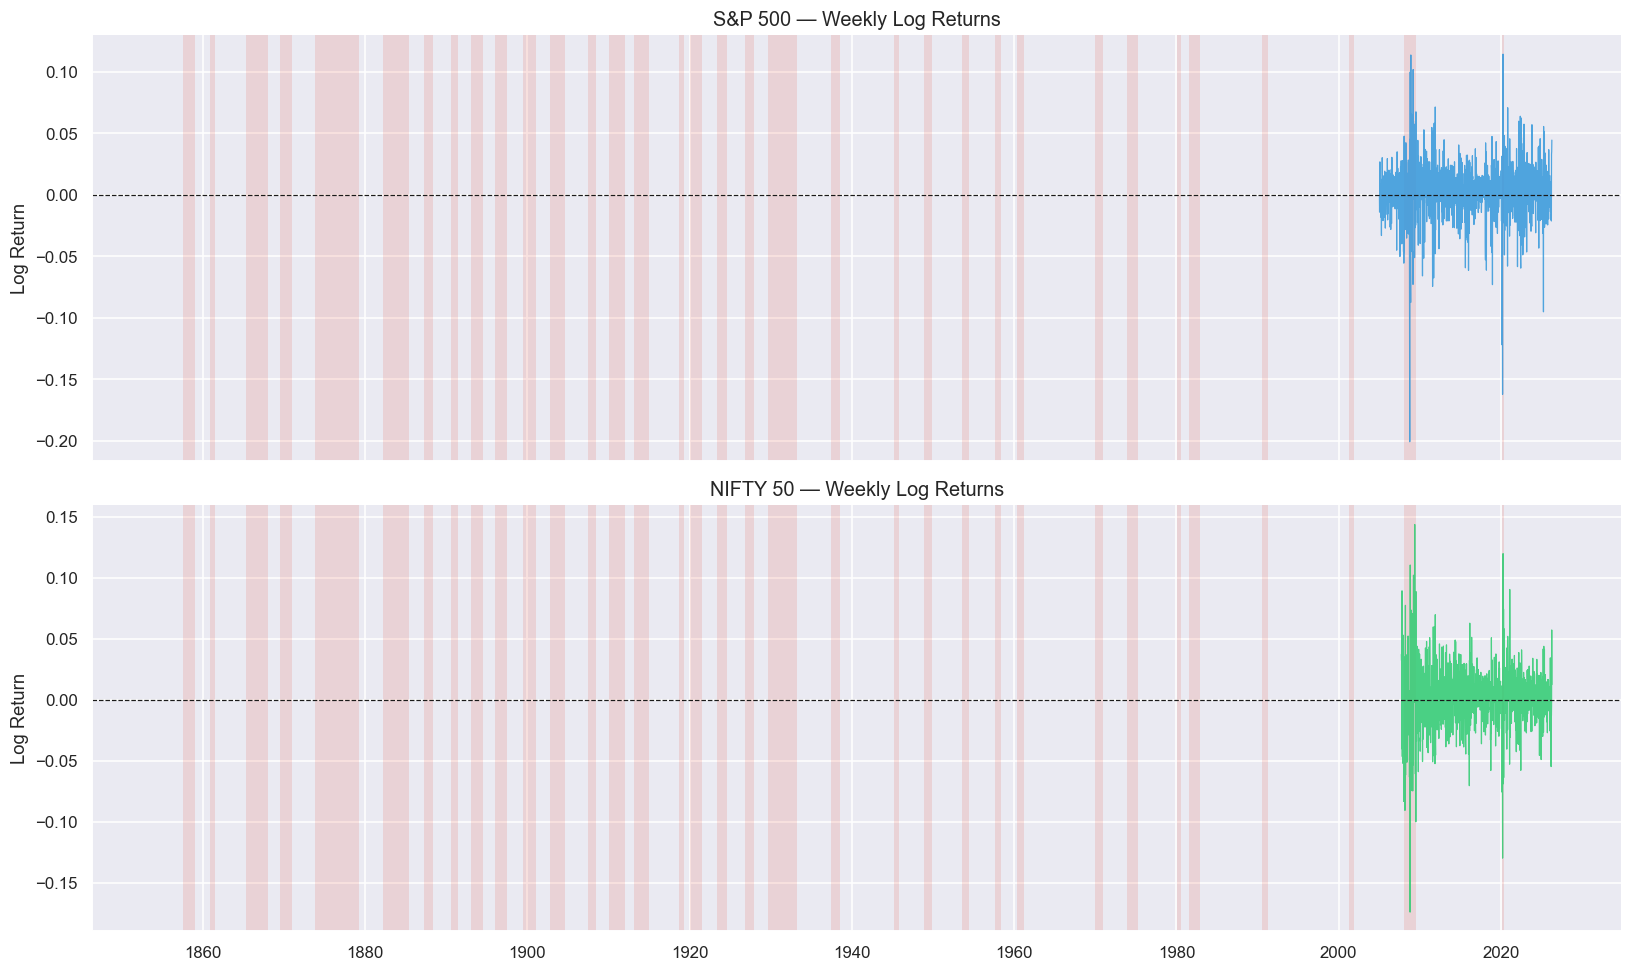

In [6]:
def shade_recessions(ax, df_rec):
    mask = df_rec["USREC"] == 1
    in_rec, start = False, None
    for date, val in mask.items():
        if val and not in_rec:  start, in_rec = date, True
        elif not val and in_rec:
            ax.axvspan(start, date, color=RECESSION_COLOR, alpha=0.15, lw=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, df_rec.index[-1], color=RECESSION_COLOR, alpha=0.15, lw=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(sp500.index, sp500["Log_Return"], color=SP_COLOR, lw=0.8, alpha=0.85)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_title("S&P 500 — Weekly Log Returns", fontsize=13); axes[0].set_ylabel("Log Return")
shade_recessions(axes[0], rec)
axes[1].plot(nifty.index, nifty["Log_Return"], color=NIF_COLOR, lw=0.8, alpha=0.85)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_title("NIFTY 50 — Weekly Log Returns", fontsize=13); axes[1].set_ylabel("Log Return")
shade_recessions(axes[1], rec)
plt.tight_layout(); plt.show()


## 6. Return Distributions

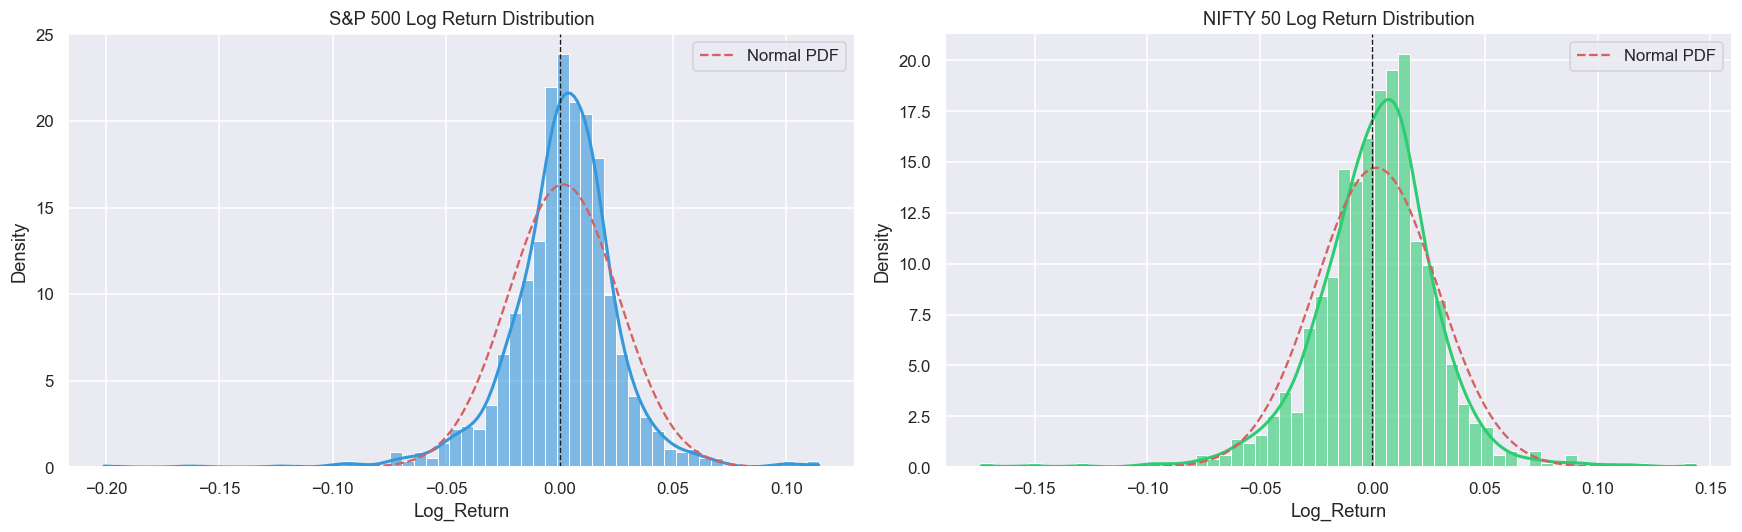

Excess kurtosis: {'S&P 500': np.float64(8.411), 'NIFTY 50': np.float64(5.049)}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, name, c in [
        (axes[0], sp500["Log_Return"], "S&P 500",  SP_COLOR),
        (axes[1], nifty["Log_Return"],  "NIFTY 50", NIF_COLOR)]:
    sns.histplot(col, bins=60, kde=True, ax=ax, color=c, stat="density", alpha=0.6,
                 line_kws={"lw": 2})
    xs = np.linspace(col.min(), col.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, col.mean(), col.std()), "r--", lw=1.5, label="Normal PDF")
    ax.axvline(0, color="k", lw=0.9, ls="--"); ax.set_title(f"{name} Log Return Distribution")
    ax.legend()
plt.tight_layout(); plt.show()
print("Excess kurtosis:", {n: round(c.kurtosis(),3)
      for n, c in [("S&P 500", sp500["Log_Return"]),("NIFTY 50", nifty["Log_Return"])]})


## 7. Q–Q Plots (Normality Check)

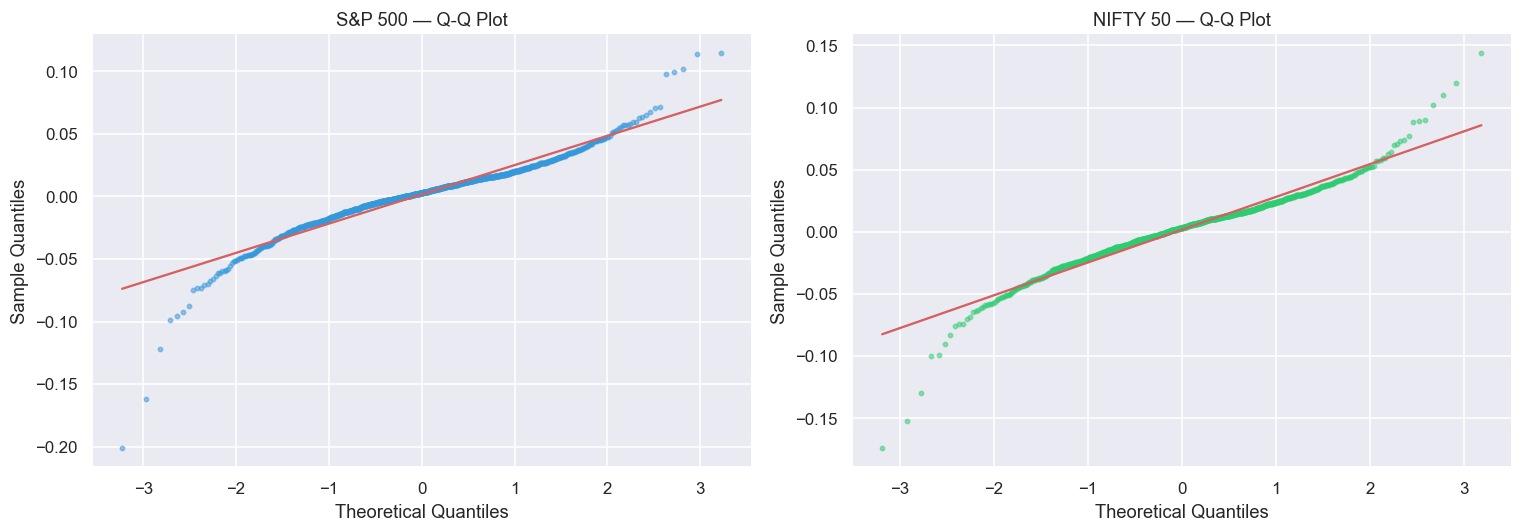

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, name, c in [
        (axes[0], sp500["Log_Return"], "S&P 500",  SP_COLOR),
        (axes[1], nifty["Log_Return"],  "NIFTY 50", NIF_COLOR)]:
    (osm, osr), (slope, intercept, _) = stats.probplot(col)
    ax.scatter(osm, osr, s=8, alpha=0.5, c=c)
    ax.plot(osm, slope*np.array(osm)+intercept, "r-", lw=1.5)
    ax.set_title(f"{name} — Q-Q Plot"); ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
plt.tight_layout(); plt.show()


## 8. Rolling Volatility (21-Week Window)

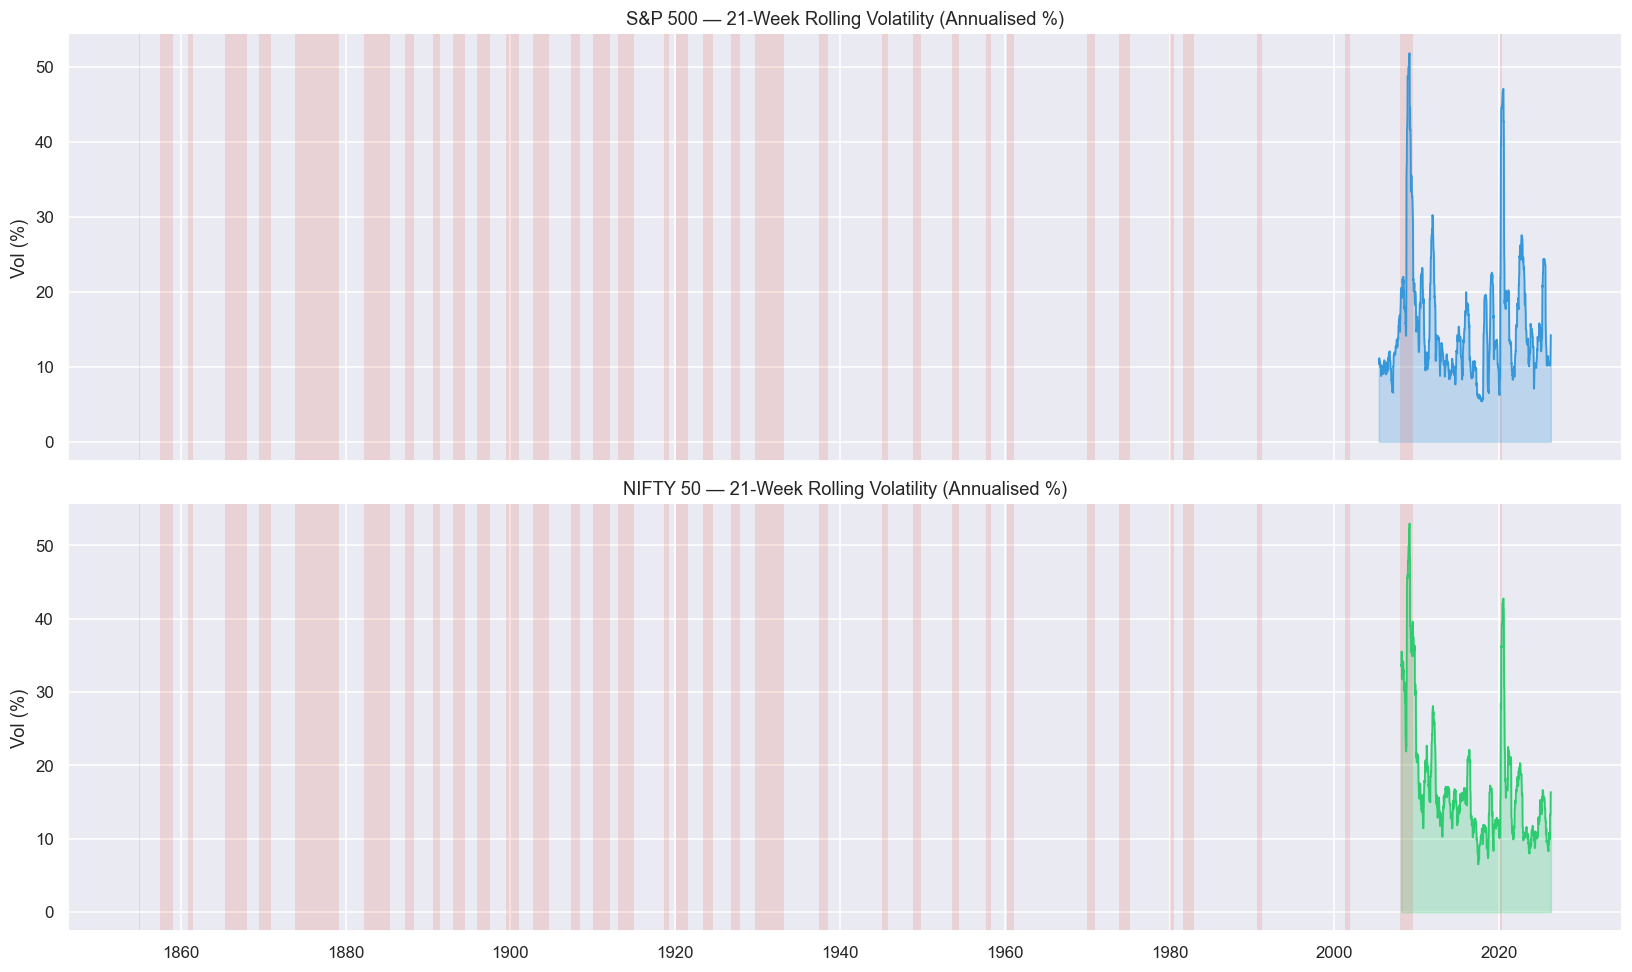

In [9]:
def shade_recessions(ax, df_rec):
    mask = df_rec["USREC"] == 1
    in_rec, start = False, None
    for date, val in mask.items():
        if val and not in_rec:  start, in_rec = date, True
        elif not val and in_rec:
            ax.axvspan(start, date, color=RECESSION_COLOR, alpha=0.15, lw=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, df_rec.index[-1], color=RECESSION_COLOR, alpha=0.15, lw=0)

WINDOW = 21
sp500["RollingVol"] = sp500["Log_Return"].rolling(WINDOW).std() * np.sqrt(52) * 100
nifty["RollingVol"]  = nifty["Log_Return"].rolling(WINDOW).std()  * np.sqrt(52) * 100
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(sp500.index, sp500["RollingVol"], color=SP_COLOR, lw=1.2)
axes[0].fill_between(sp500.index, 0, sp500["RollingVol"], color=SP_COLOR, alpha=0.25)
axes[0].set_title("S&P 500 — 21-Week Rolling Volatility (Annualised %)"); axes[0].set_ylabel("Vol (%)")
shade_recessions(axes[0], rec)
axes[1].plot(nifty.index, nifty["RollingVol"], color=NIF_COLOR, lw=1.2)
axes[1].fill_between(nifty.index, 0, nifty["RollingVol"], color=NIF_COLOR, alpha=0.25)
axes[1].set_title("NIFTY 50 — 21-Week Rolling Volatility (Annualised %)"); axes[1].set_ylabel("Vol (%)")
shade_recessions(axes[1], rec)
plt.tight_layout(); plt.show()


## 9. Autocorrelation (ACF) of Returns & Squared Returns

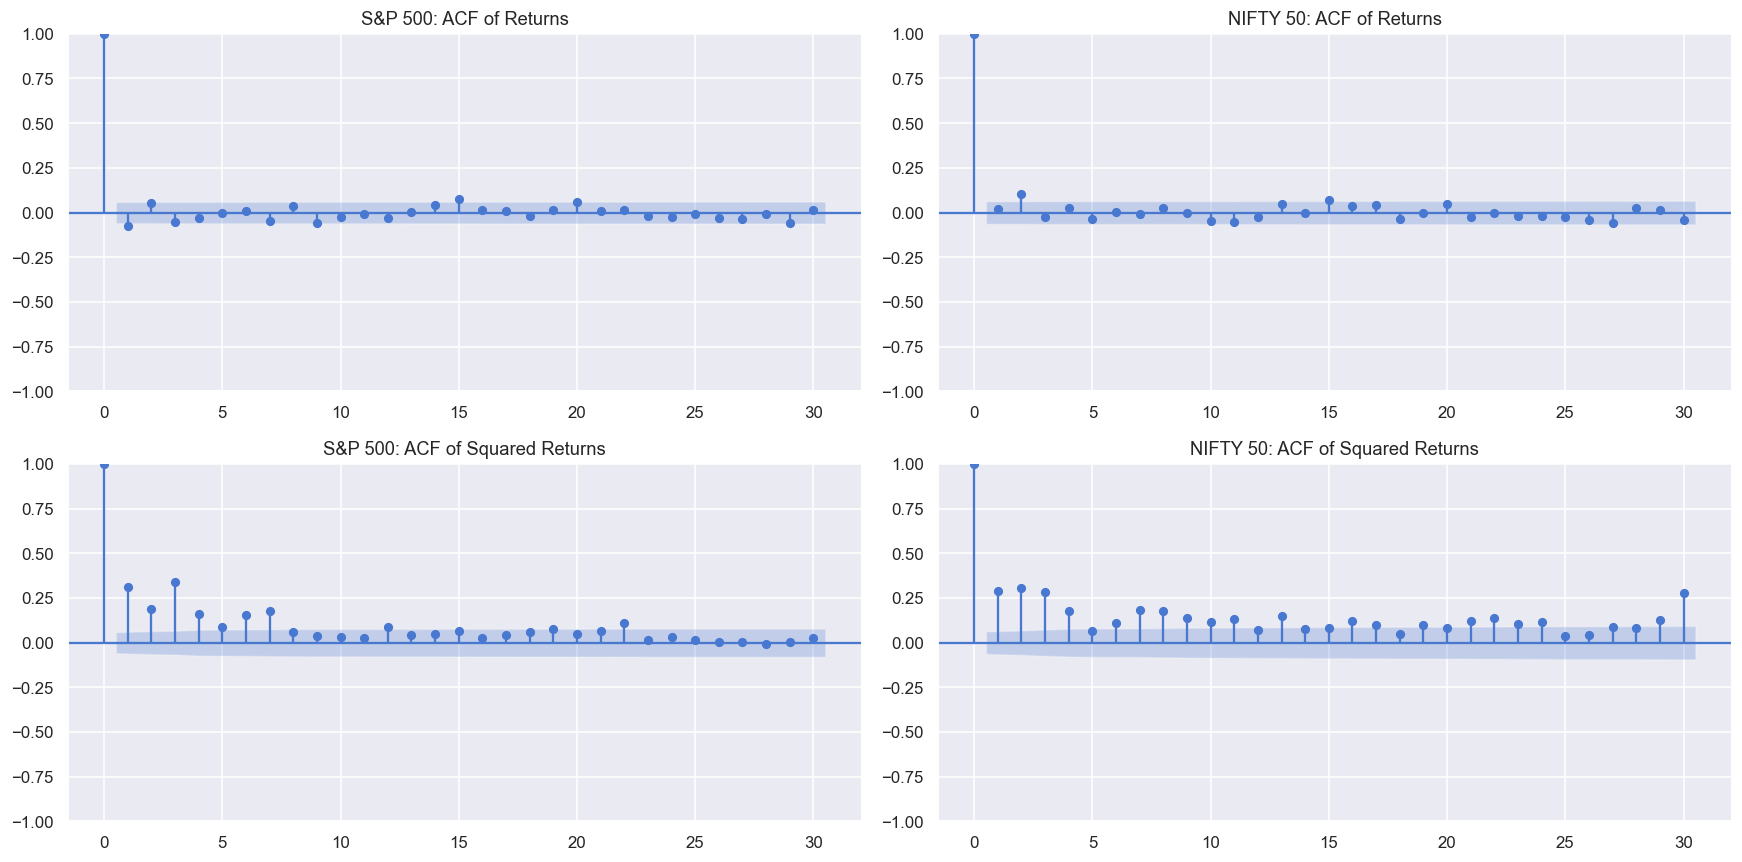

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for col_idx, (df, name) in enumerate([(sp500, "S&P 500"), (nifty, "NIFTY 50")]):
    plot_acf(df["Log_Return"],    lags=30, ax=axes[0][col_idx], title=f"{name}: ACF of Returns")
    plot_acf(df["Log_Return"]**2, lags=30, ax=axes[1][col_idx], title=f"{name}: ACF of Squared Returns")
plt.tight_layout(); plt.show()


## 10. Correlation Between Markets

Pearson correlation: nan


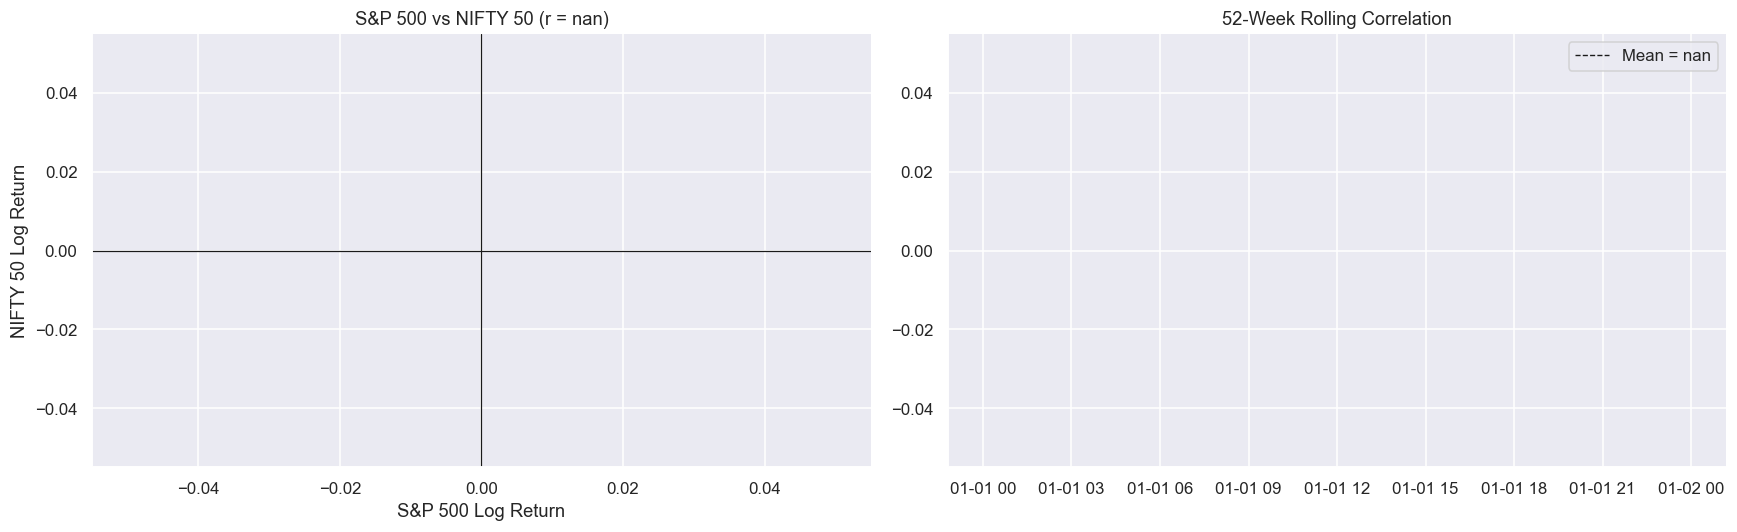

In [11]:
combined = pd.DataFrame({
    "S&P 500": sp500["Log_Return"],
    "NIFTY 50": nifty["Log_Return"],
}).dropna()
r = combined.corr().loc["S&P 500", "NIFTY 50"]
print(f"Pearson correlation: {r:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(combined["S&P 500"], combined["NIFTY 50"], alpha=0.4, s=18, color="mediumpurple")
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("S&P 500 Log Return"); axes[0].set_ylabel("NIFTY 50 Log Return")
axes[0].set_title(f"S&P 500 vs NIFTY 50 (r = {r:.3f})")

rolling_corr = combined["S&P 500"].rolling(52).corr(combined["NIFTY 50"])
axes[1].plot(rolling_corr.index, rolling_corr, color="mediumpurple", lw=1.3)
axes[1].axhline(rolling_corr.mean(), color="k", lw=0.9, ls="--",
                label=f"Mean = {rolling_corr.mean():.3f}")
axes[1].set_title("52-Week Rolling Correlation"); axes[1].legend()
plt.tight_layout(); plt.show()


## 11. Extreme Returns During NBER Recessions

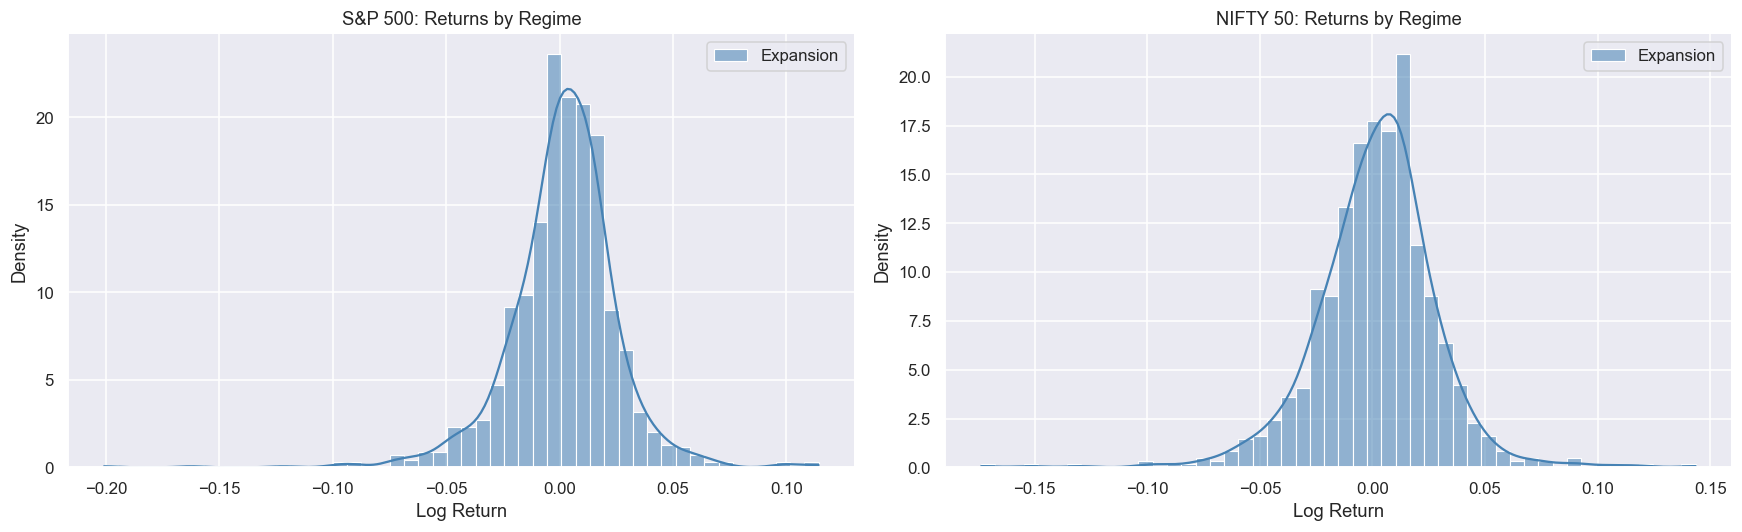


S&P 500 by regime:


,Expansion,Recession
count,1110.00000,0.0
mean,0.00162,NaN
std,0.02442,NaN
min,-0.20084,NaN
25%,-0.00966,NaN
50%,0.00283,NaN
75%,0.01459,NaN
max,0.11424,NaN



NIFTY 50 by regime:


,Expansion,Recession
count,969.00000,0.0
mean,0.00167,NaN
std,0.02710,NaN
min,-0.17375,NaN
25%,-0.01235,NaN
50%,0.00331,NaN
75%,0.01589,NaN
max,0.14357,NaN


In [12]:
rec_weekly = rec.resample("W").ffill()
sp_aligned = sp500["Log_Return"].to_frame().join(rec_weekly, how="left").fillna(0)
ni_aligned  = nifty["Log_Return"].to_frame().join(rec_weekly,  how="left").fillna(0)

sp_bull = sp_aligned.loc[sp_aligned["USREC"]==0,"Log_Return"]
sp_bear = sp_aligned.loc[sp_aligned["USREC"]==1,"Log_Return"]
ni_bull = ni_aligned.loc[ni_aligned["USREC"]==0,"Log_Return"]
ni_bear = ni_aligned.loc[ni_aligned["USREC"]==1,"Log_Return"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, bull, bear, name in [(axes[0],sp_bull,sp_bear,"S&P 500"),(axes[1],ni_bull,ni_bear,"NIFTY 50")]:
    sns.histplot(bull, bins=50, kde=True, ax=ax, color="steelblue", label="Expansion", stat="density", alpha=0.55)
    sns.histplot(bear, bins=50, kde=True, ax=ax, color=RECESSION_COLOR, label="Recession", stat="density", alpha=0.55)
    ax.set_title(f"{name}: Returns by Regime"); ax.set_xlabel("Log Return"); ax.legend()
plt.tight_layout(); plt.show()

print("\nS&P 500 by regime:")
display(pd.DataFrame({"Expansion": sp_bull.describe(),"Recession": sp_bear.describe()}).round(5))
print("\nNIFTY 50 by regime:")
display(pd.DataFrame({"Expansion": ni_bull.describe(),"Recession": ni_bear.describe()}).round(5))
